# Ejemplo
Una partícula parte del reposo sobre un plano inclinado uniforme, cuyo ángulo $\theta$ cambia con una tasa constante de 
$$\frac{d\theta}{dt}=\omega <0$$
Al final de $t$ segundos, la posición del objeto está dada por 
$$x(t)=-\frac{g}{2\omega^{2}}\left(\frac{e^{\omega t}-e^{-\omega t}}{2}-\sin(\omega t)\right)$$
suponga que la partícula se desplazo 1.7 pies en 1 segundo. Encuentre con una exactitud de $10^{-5}$, la tasa $\omega$ a la que $\theta$ cambia. Suponga que $g=32,17pies/s^{2}$}

1.Usando el método de la bisección. Determine el numero de iteraciones necesarias si la exactitud es de $10^{-5}$. Y calcule la aproximación.


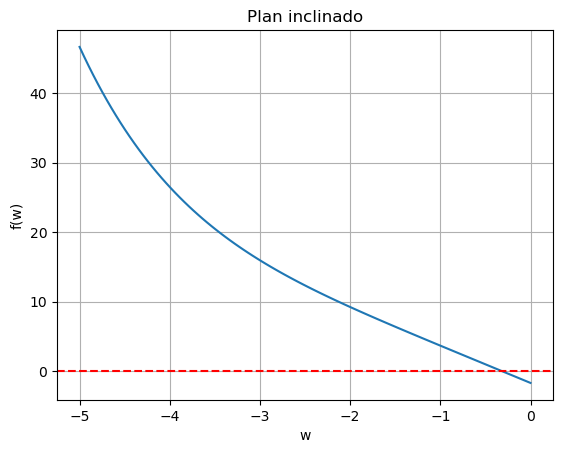

In [2]:
# Importa librerías para graficar y cálculo numérico
import matplotlib.pyplot as plt
import numpy as np

# Dato del problema: gravedad en pies/s^2
g = 32.17
# Dato del problema: desplazamiento en pies
x = 1.7

# Se construye un rango de valores para omega (negativos)
w = np.linspace(-5, -1e-3, 100)

# Función del problema en términos de omega:
# f(w) = -g/(2w^2) * ( (e^w - e^-w)/2 - sin(w) ) - x
# Se busca f(w)=0
omega = lambda w: -g / (2*w**2) * ((np.exp(w) - np.exp(-w)) / 2 - np.sin(w)) - x

# Gráfica de la función para estimar intervalo con cambio de signo
plt.plot(w, omega(w))
plt.axhline(y=0, color='red', linestyle='--')  # línea horizontal y=0
plt.xlabel('w')
plt.ylabel('f(w)')
plt.title('Plan inclinado')
plt.grid()
plt.show()

## Método de Posición Falsa

El método de posición falsa se basa en el **teorema de valor intermedio**. Supongamos que $f$ es una función continúa en el intervalo $[a, b]$, con $f(a)$ y $f(b)$ de signos opuestos. De acuerdo al teorema de valor intermedio, existe al menos un número $\alpha \in (a, b)$ tal que $f(\alpha) = 0$.

<div align="center">
  <img src="imagenes/p_f.png" width="400">
</div>

# Método de Posición Falsa

A partir de la gráfica, usando **triángulos semejantes**, se estima que:

$$
\frac{f(a)}{c-a} = \frac{-f(b)}{b-c}
$$

Equivalentemente:

$$
\frac{f(a)}{c-a} = \frac{f(b)}{c-b}
$$

Despejando \(c\):

$$
c = b - f(b)\frac{(a-b)}{f(a)-f(b)}
$$

---

## Aplicación del teorema de Bolzano

Aplicamos nuevamente el **teorema de Bolzano** haciendo una división del intervalo.

- Si  

$$
f(a)f(c) < 0
$$

entonces

$$
\alpha \in [a,c]
$$

- En caso contrario

$$
\alpha \in [c,b]
$$

---

## Criterio de parada

Este proceso se repite hasta que se cumpla una o varias de las siguientes condiciones para una tolerancia \( \varepsilon \):

1. Número máximo de iteraciones \(N\)

2. 

$$
|f(c_n)| < \varepsilon
$$

3. 

$$
|c_n - c_{n-1}| < \varepsilon
$$

In [14]:
def Biseccion(f, a, b, tol):
    # Verifica condición de Bolzano: signos opuestos en los extremos
    if f(a) * f(b) > 0:
        print('No se cumple el teorema de Bolzano: no se garantiza una raíz en este intervalo.')
    else:
        # Itera mientras el tamaño del intervalo sea mayor que la tolerancia
        while abs(b - a) > tol:
            # Punto medio del intervalo actual
            p = (a + b) / 2

            # Si hay cambio de signo entre a y p, la raíz está en [a, p]
            if f(a) * f(p) < 0:
                b = p
            else:
                # En caso contrario, está en [p, b]
                a = p

        # Muestra aproximación final
        print(f'La solución aproximada de la función es: {p}')
    return

In [23]:
def posicion_falsa(f, a, b, tol):
    # Verifica condición de Bolzano
    if f(a)*f(b) > 0:
        print('No hay nada')
    else:
        # Primera aproximación por fórmula de posición falsa (regla falsa)
        p = b - f(b)*(a-b) / (f(a)-f(b))

        # Itera hasta que el residuo en p sea menor que la tolerancia
        while abs(f(p)) > tol:
            # Recalcula p con los extremos actuales
            p = b - f(b)*(a-b)/(f(a)-f(b))

            # Selecciona el nuevo subintervalo con cambio de signo
            if f(a)*f(p) < 0:
                b = p
            else:
                a = p

        # Muestra aproximación final
        print(f'La solucion de la funcion: {p}')
    return

In [44]:
fpro = lambda x: x**10-1
Biseccion(fpro, 0, 3, 1e-6)

La solución aproximada de la función es: 0.9999997615814209


In [37]:
fpro = lambda x: x**10-1
posicion_falsa(fpro, 0, 3, 1e-6)

La solucion de la funcion: 0.9999999000267046


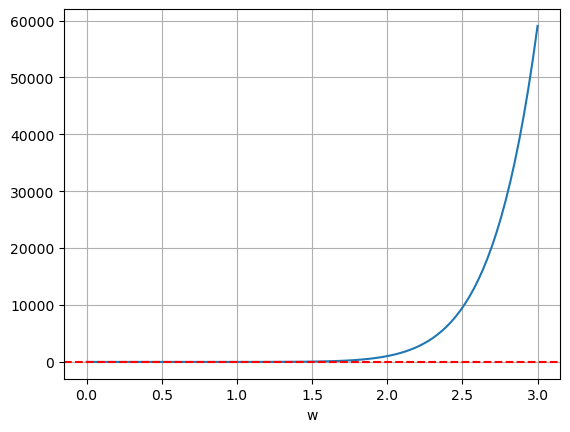

In [43]:
# Crea puntos para graficar la función de prueba
x = np.linspace(0, 3, 100)

# Grafica fpro(x) y la línea y=0 para visualizar cruces con el eje x
plt.plot(x, fpro(x))
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('w')
plt.grid()
plt.show()

# Ejemplo:

Calcular el primer cero positivo diferente del numero cero de la funcion $f(x)=sin(x)$

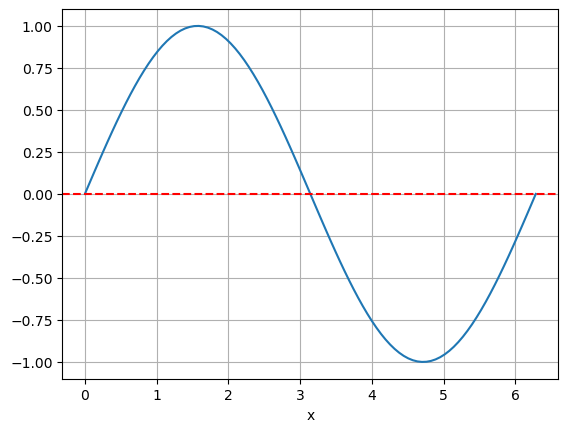

In [38]:
# Rango para graficar sin(x) entre 0 y 2π
x = np.linspace(0, 2*np.pi, 100)

# Grafica seno y eje x para ubicar ceros
plt.plot(x, np.sin(x))
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('x')
plt.grid()
plt.show()

In [ ]:
# Define la función seno
f = lambda x: np.sin(x)

# Busca un cero en el intervalo [3, 3.5] (cerca de π)
Biseccion(f, 3, 3.5, 1e-8)

La solución aproximada de la función es: 3.1415926590561867
